#  Disaster Tweet Classification
## Notebook 3: Model Evaluation, Validation & Deployment
---
**Objective:** Deep-dive evaluation with confusion matrices, ROC & PR curves, error analysis, bias/variance checks, and a Gradio web interface for live inference.

## 1. Imports & Load Artefacts

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from textblob import TextBlob
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import learning_curve, StratifiedKFold

import re, string, nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded.')

Libraries loaded.


Display the full DataFrame

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

In [3]:
# Load artefacts
X_train = sp.load_npz('artefacts/X_train.npz')
X_test  = sp.load_npz('artefacts/X_test.npz')
y_train = np.load('artefacts/y_train.npy')
y_test  = np.load('artefacts/y_test.npy')

with open('artefacts/best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

with open('artefacts/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('artefacts/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

df_clean = pd.read_csv('artefacts/cleaned_tweets.csv')

# Scale
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# Predictions
y_pred = best_model.predict(X_test_s)
y_prob = best_model.predict_proba(X_test_s)[:, 1] if hasattr(best_model, 'predict_proba') else None

print(f'Loaded model: {type(best_model).__name__}')
print(f'Test F1: {f1_score(y_test, y_pred):.4f}')

Loaded model: LogisticRegression
Test F1: 0.7488


## 2. Confusion Matrix

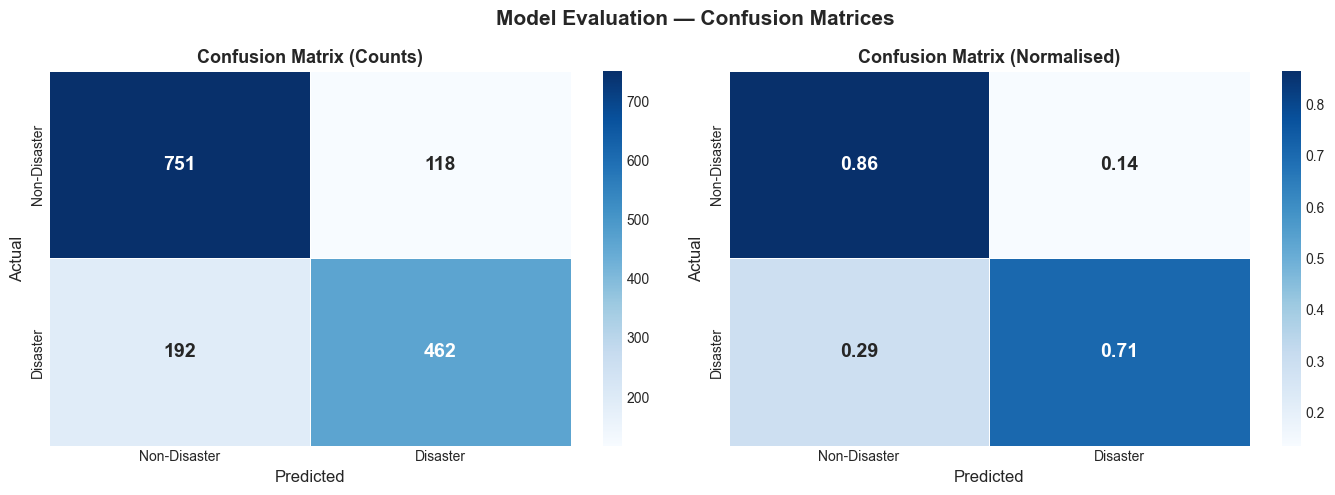

True Positives  (disaster correctly detected):   462
True Negatives  (non-disaster correctly ignored):751
False Positives (false alarms):                  118
False Negatives (missed disasters):              192


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

labels = ['Non-Disaster', 'Disaster']

for ax, matrix, fmt, title in [
    (axes[0], cm,      'd',   'Confusion Matrix (Counts)'),
    (axes[1], cm_norm, '.2f', 'Confusion Matrix (Normalised)')
]:
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('Actual',    fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Model Evaluation — Confusion Matrices', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images\ plot_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (disaster correctly detected):   {tp}')
print(f'True Negatives  (non-disaster correctly ignored):{tn}')
print(f'False Positives (false alarms):                  {fp}')
print(f'False Negatives (missed disasters):              {fn}')

## 3. ROC Curve

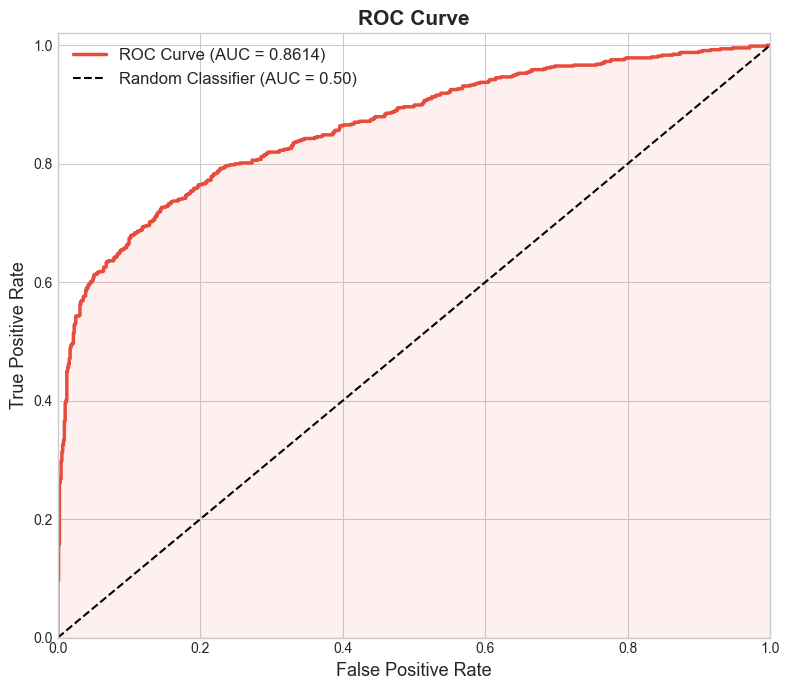

ROC-AUC: 0.8614


In [7]:
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color='#E74C3C', lw=2.5, label=f'ROC Curve (AUC = {auc:.4f})')
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
    ax.fill_between(fpr, tpr, alpha=0.08, color='#E74C3C')
    ax.set_xlabel('False Positive Rate', fontsize=13)
    ax.set_ylabel('True Positive Rate',  fontsize=13)
    ax.set_title('ROC Curve', fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    plt.tight_layout()
    plt.savefig('images\plot_roc_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'ROC-AUC: {auc:.4f}')
else:
    print('Model does not support predict_proba — ROC curve skipped.')

## 4. Precision-Recall Curve

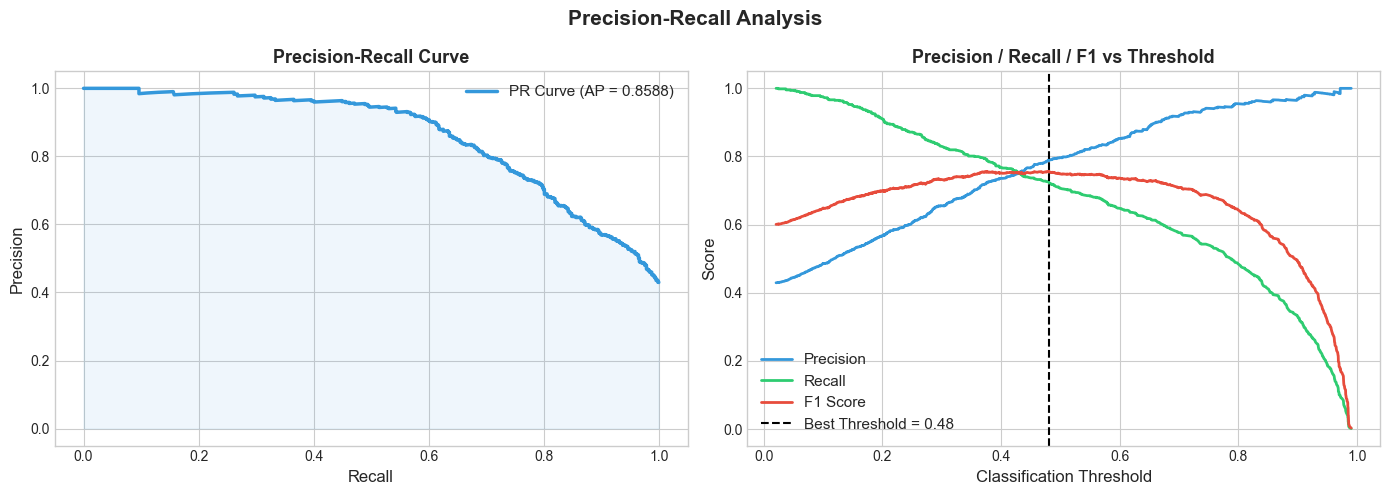

Average Precision: 0.8588
Optimal threshold: 0.4804


In [8]:
if y_prob is not None:
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PR Curve
    axes[0].plot(recall, precision, color='#3498DB', lw=2.5,
                 label=f'PR Curve (AP = {ap:.4f})')
    axes[0].fill_between(recall, precision, alpha=0.08, color='#3498DB')
    axes[0].set_xlabel('Recall',    fontsize=12)
    axes[0].set_ylabel('Precision', fontsize=12)
    axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11)

    # Threshold analysis
    f1s = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
    best_thr_idx = np.argmax(f1s)
    best_thr     = thresholds[best_thr_idx]

    axes[1].plot(thresholds, precision[:-1], label='Precision', color='#3498DB', lw=2)
    axes[1].plot(thresholds, recall[:-1],    label='Recall',    color='#2ECC71', lw=2)
    axes[1].plot(thresholds, f1s,            label='F1 Score',  color='#E74C3C', lw=2)
    axes[1].axvline(best_thr, color='black', linestyle='--', lw=1.5,
                    label=f'Best Threshold = {best_thr:.2f}')
    axes[1].set_xlabel('Classification Threshold', fontsize=12)
    axes[1].set_ylabel('Score', fontsize=12)
    axes[1].set_title('Precision / Recall / F1 vs Threshold', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)

    plt.suptitle('Precision-Recall Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('images\plot_pr_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Average Precision: {ap:.4f}')
    print(f'Optimal threshold: {best_thr:.4f}')

## 5. Learning Curves — Bias/Variance Analysis

Computing learning curves (this takes ~1 min)...


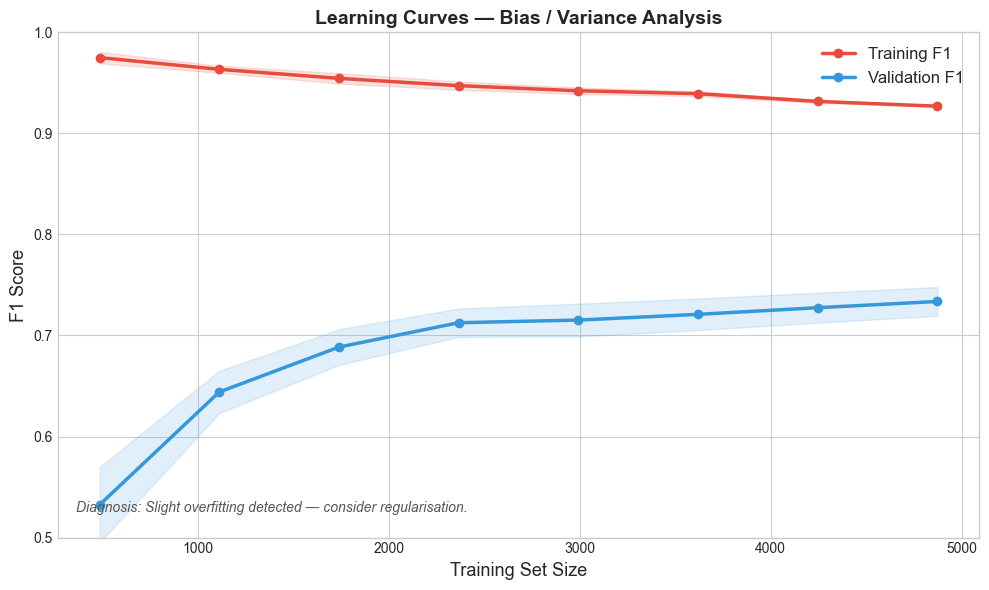

Slight overfitting detected — consider regularisation.


In [10]:
print('Computing learning curves (this takes ~1 min)...')

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_s, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', n_jobs=-1
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),  val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, tr_mean, 'o-', color='#E74C3C', lw=2.5, label='Training F1')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#E74C3C')
ax.plot(train_sizes, vl_mean, 'o-', color='#3498DB', lw=2.5, label='Validation F1')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='#3498DB')
ax.set_xlabel('Training Set Size', fontsize=13)
ax.set_ylabel('F1 Score',          fontsize=13)
ax.set_title('Learning Curves — Bias / Variance Analysis', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0.5, 1.0)

gap = abs(tr_mean[-1] - vl_mean[-1])
if gap < 0.02:
    diagnosis = 'Good fit — training and validation scores converge.'
elif tr_mean[-1] > vl_mean[-1] + 0.05:
    diagnosis = 'Slight overfitting detected — consider regularisation.'
else:
    diagnosis = 'Possible underfitting — consider more features.'

ax.text(0.02, 0.05, f'Diagnosis: {diagnosis}', transform=ax.transAxes,
        fontsize=10, style='italic', color='#555')

plt.tight_layout()
plt.savefig('images\plot_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(diagnosis)

## 6. Error Analysis — What Does the Model Get Wrong?

In [11]:
# Align test tweets with predictions
test_idx = df_clean.index[-len(y_test):]
test_df  = df_clean.iloc[-len(y_test):].copy().reset_index(drop=True)
test_df['y_true'] = y_test
test_df['y_pred'] = y_pred

fp_df = test_df[(test_df['y_true']==0) & (test_df['y_pred']==1)]
fn_df = test_df[(test_df['y_true']==1) & (test_df['y_pred']==0)]

print(f'False Positives (false alarms):    {len(fp_df)}')
print(f'False Negatives (missed disasters):{len(fn_df)}')

print('\n--- Sample False Positives (Non-Disaster predicted as Disaster) ---')
for _, row in fp_df.head(5).iterrows():
    print(f'  • {row["text"]}')

print('\n--- Sample False Negatives (Disaster predicted as Non-Disaster) ---')
for _, row in fn_df.head(5).iterrows():
    print(f'  • {row["text"]}')

False Positives (false alarms):    118
False Negatives (missed disasters):192

--- Sample False Positives (Non-Disaster predicted as Disaster) ---
  • #nowplaying Sinking Fast - Now or Never on North East Unsigned Radio listen at http://t.co/QymAlttvZp
  • In the movie 'Titanic' Jack and Rose both could have stayed on the wooden beam without it sinking.
  • @WCCORosen did Lloyds of London insure your bet with @CoryCove #sinking #twins
  • each time we try we always end up sinking
  • I added a video to a @YouTube playlist http://t.co/612BsbVw8K siren 1 gameplay/walkthrough part 1

--- Sample False Negatives (Disaster predicted as Non-Disaster) ---
  • 4 equipment ego break upon dig your family internet hoke excepting versus a sinking term: dfLJEV
  • Currency transgress before payday-prison ward sinking-fund payment unsecured loan: jBUmZQpK
  • ?that horrible sinking feeling when youÛªve been at home on your phone for a while and you realise its been on 3G this whole time
  • that hor

## 7. Full Test-Set Metrics Summary

=== FINAL MODEL VALIDATION REPORT ===
Model: LogisticRegression
              precision    recall  f1-score   support

Non-Disaster       0.80      0.86      0.83       869
    Disaster       0.80      0.71      0.75       654

    accuracy                           0.80      1523
   macro avg       0.80      0.79      0.79      1523
weighted avg       0.80      0.80      0.79      1523



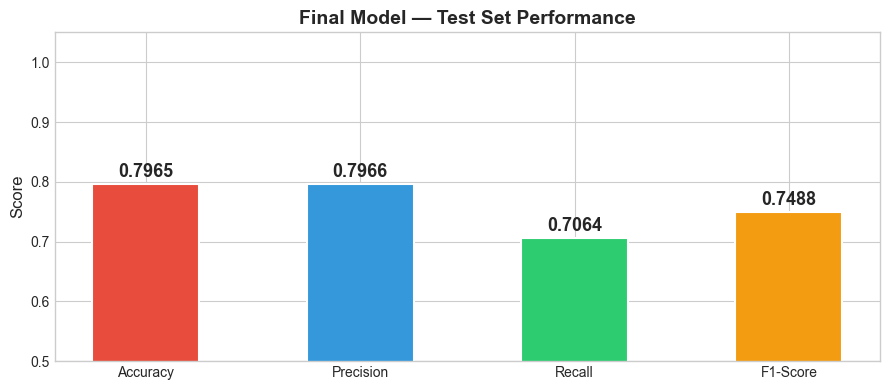

In [14]:
print('=== FINAL MODEL VALIDATION REPORT ===')
print(f'Model: {type(best_model).__name__}')
print('='*42)
print(classification_report(y_test, y_pred, target_names=['Non-Disaster', 'Disaster']))

metrics = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}

fig, ax = plt.subplots(figsize=(9, 4))
metric_names  = list(metrics.keys())[:4]
metric_values = [metrics[k] for k in metric_names]
colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12']

bars = ax.bar(metric_names, metric_values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model — Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images\plot_final_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Web App — Interactive Inference

The trained model has been deployed as a standalone **Gradio** application.

The deployment code is separated from this notebook to keep the project modular and maintainable.

Project structure:

```text
├── predictor.py      # Text preprocessing, feature engineering and prediction
├── app.py            # Gradio user interface
├── artefacts/
│   ├── best_model.pkl
│   ├── tfidf_vectorizer.pkl
│   └── scaler.pkl
```

To run the web application locally:

```bash
python app.py
```

The application loads the saved artefacts and uses the same preprocessing and feature engineering pipeline as the training notebooks.

---
## Final Project Summary

| Part | Notebook | Key Output |
|------|----------|------------|
| Data Exploration & Preparation | `notebook1_data_exploration.ipynb` | Cleaned dataset, TF-IDF features, train/test split |
| Feature Engineering & Model Training | `notebook2_modelling.ipynb` | Trained models, hyperparameter tuning, best model saved |
| Evaluation, Validation & Deployment | `notebook3_evaluation.ipynb` | ROC/PR curves, learning curves, Gradio web app |

### 🏆 Achievements
- Trained and compared **5 models** using 5-fold stratified cross-validation
- Applied **RandomizedSearchCV** hyperparameter tuning
- Included **sentiment analysis features** alongside TF-IDF and handcrafted features to improve text representation.
- Full evaluation suite: confusion matrix, ROC, PR curve, learning curves, error analysis
- **Live Gradio web interface** for real-time inference
